<a href="https://colab.research.google.com/github/JorgePeje/test-python-utec/blob/main/seguimientopresionesuspensiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# CARGAR EXCEL
# =========================================================
from google.colab import files

uploaded = files.upload()

archivo = list(uploaded.keys())[0]

df = pd.read_excel(archivo)



Saving alturasuspensiones980.xlsx to alturasuspensiones980 (1).xlsx


In [ ]:
# limpiar nombres columnas
df.columns = df.columns.str.strip()

# ver nombres reales
print(df.columns.tolist())

['Camion', 'Fecha', 'Tipo', 'AP LF', 'AP RF', 'AP LR', 'AP RR', 'AT LF', 'AT RF', 'AT LR', 'AT RR', 'PA LF', 'PA RF', 'PA LR', 'PA RR']


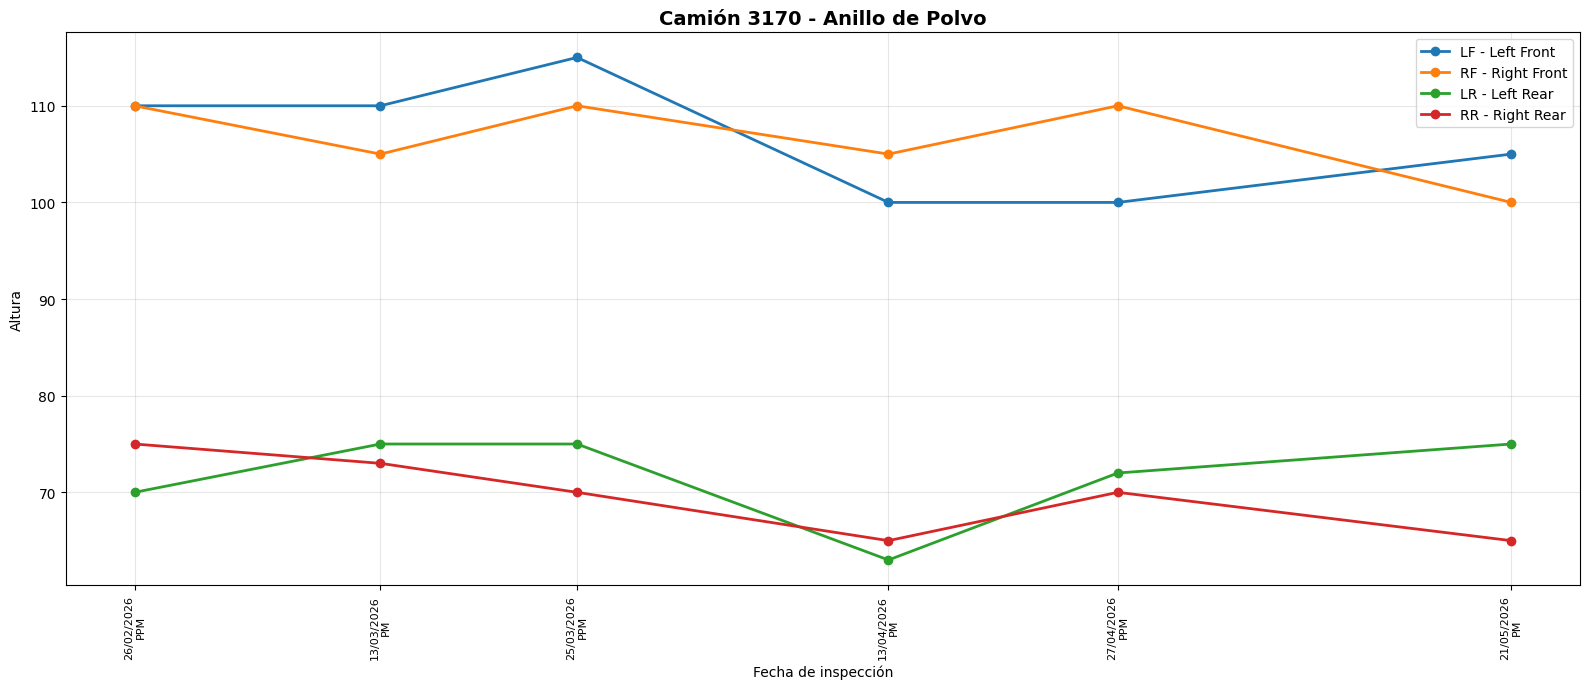

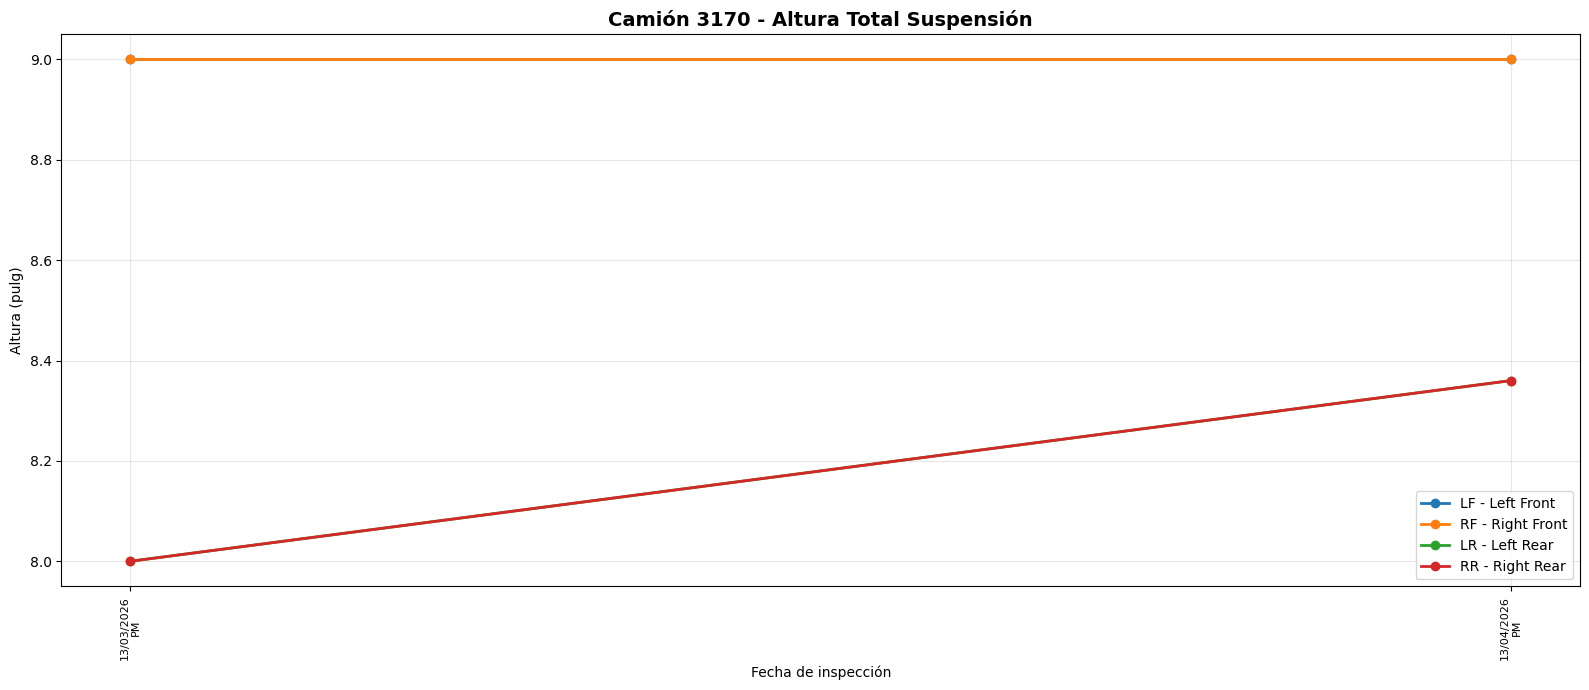

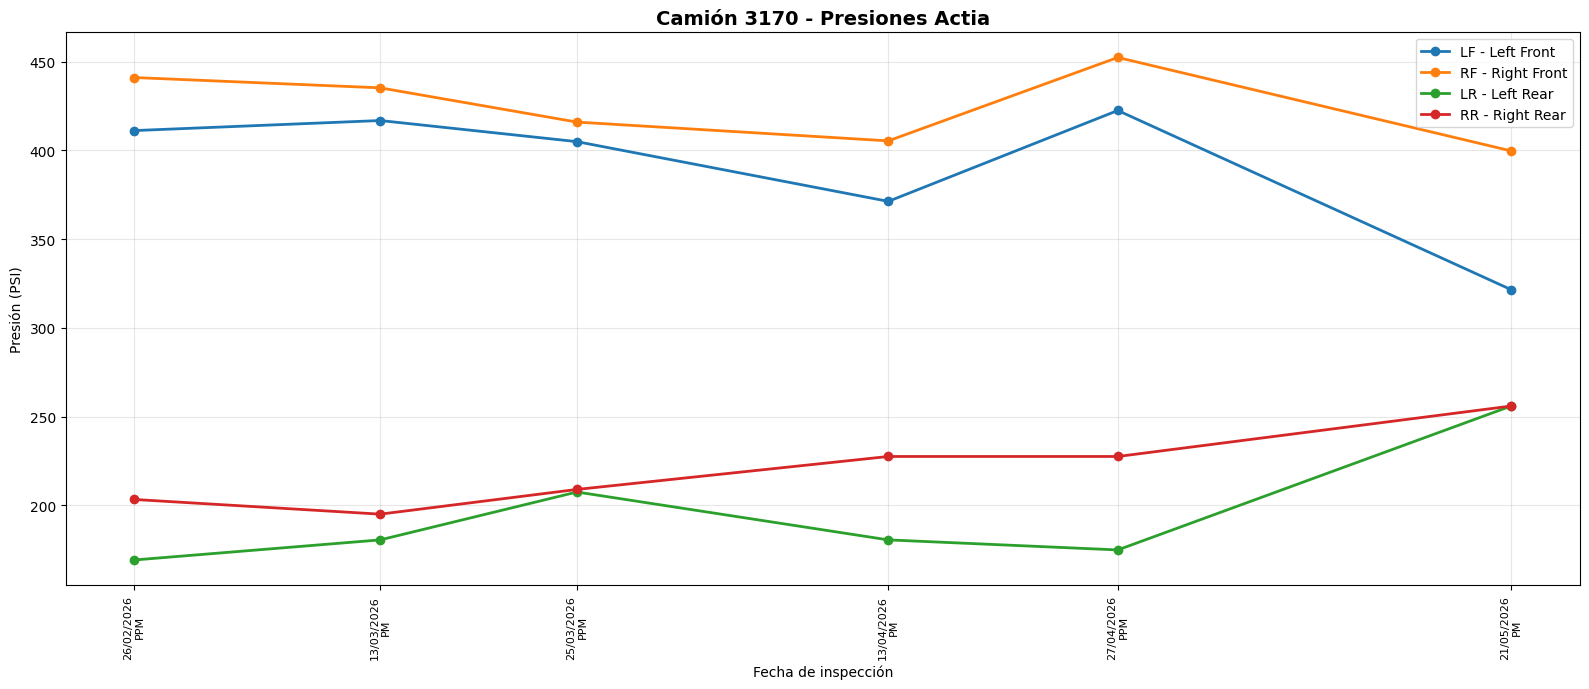

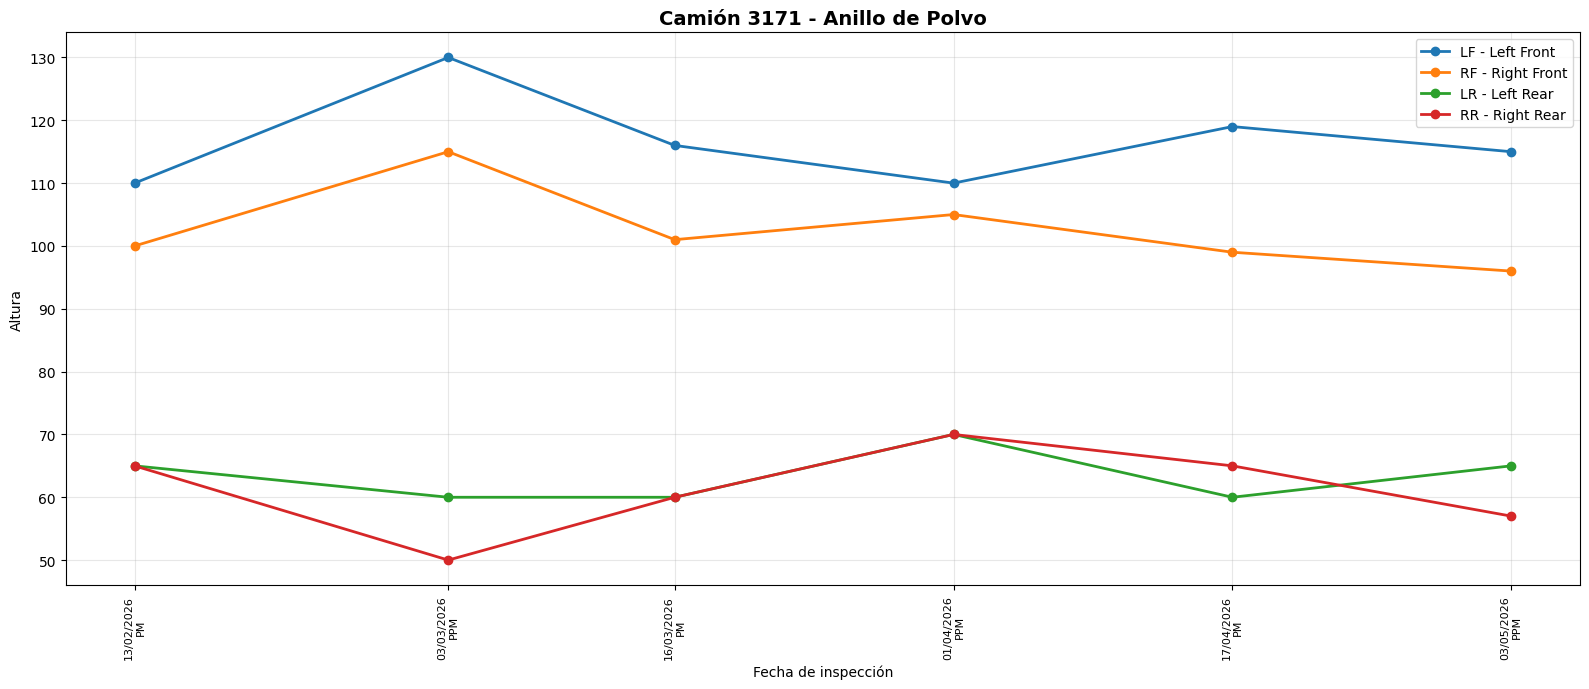

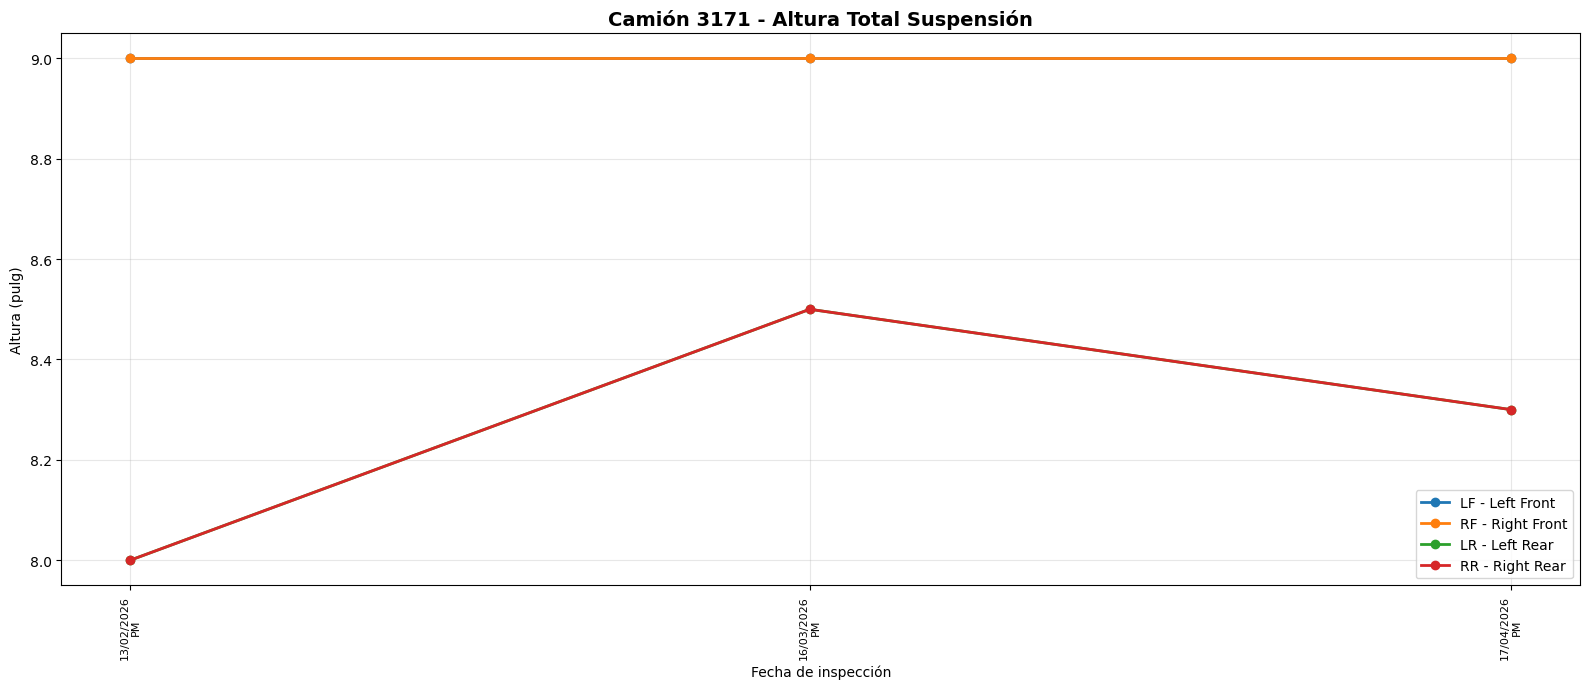

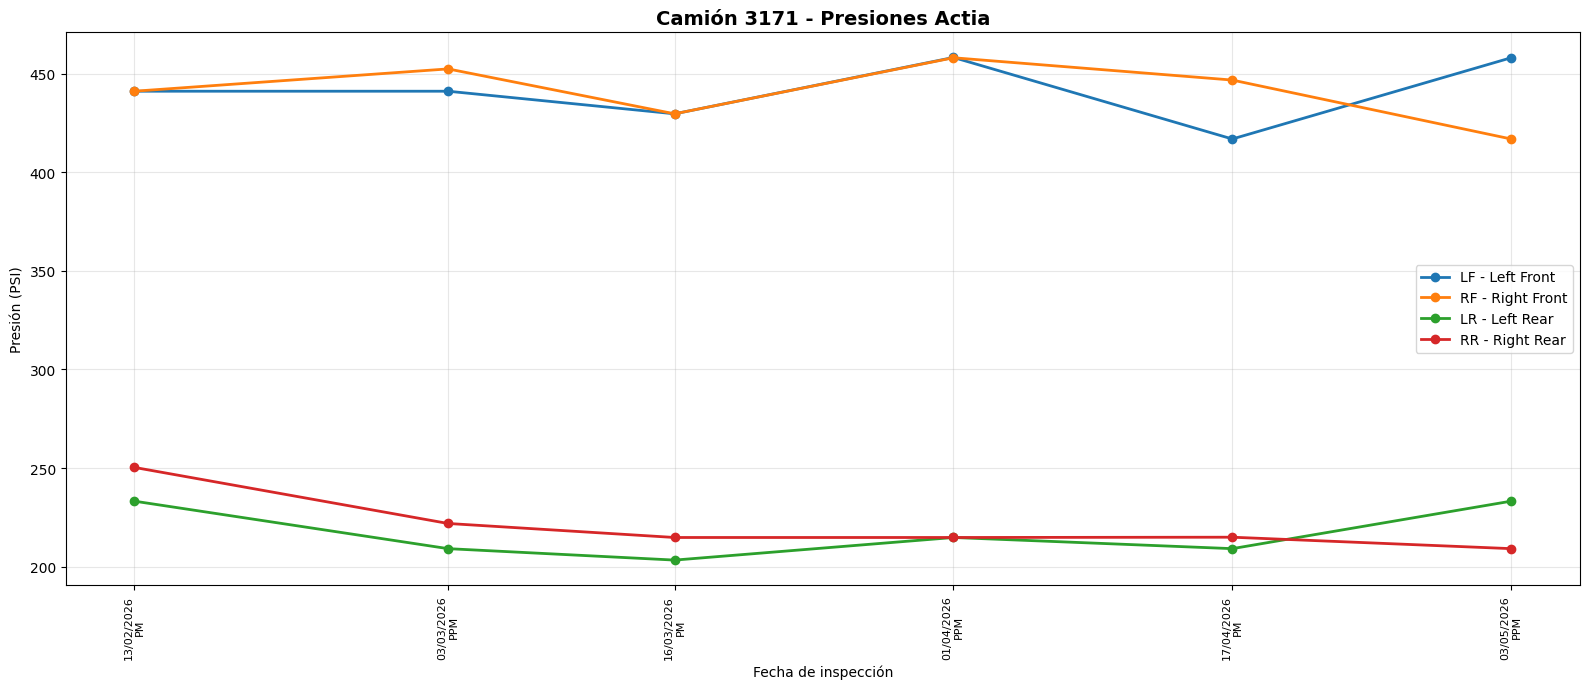

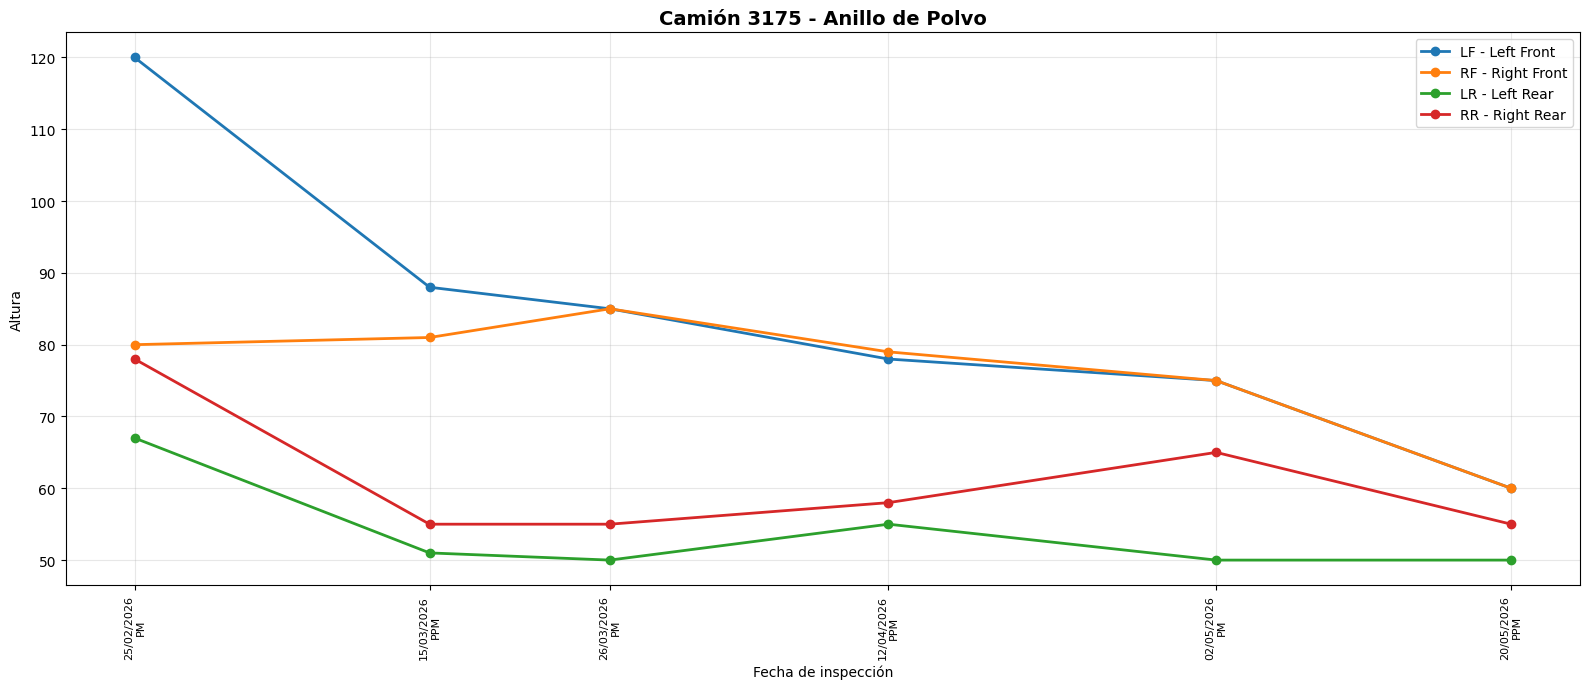

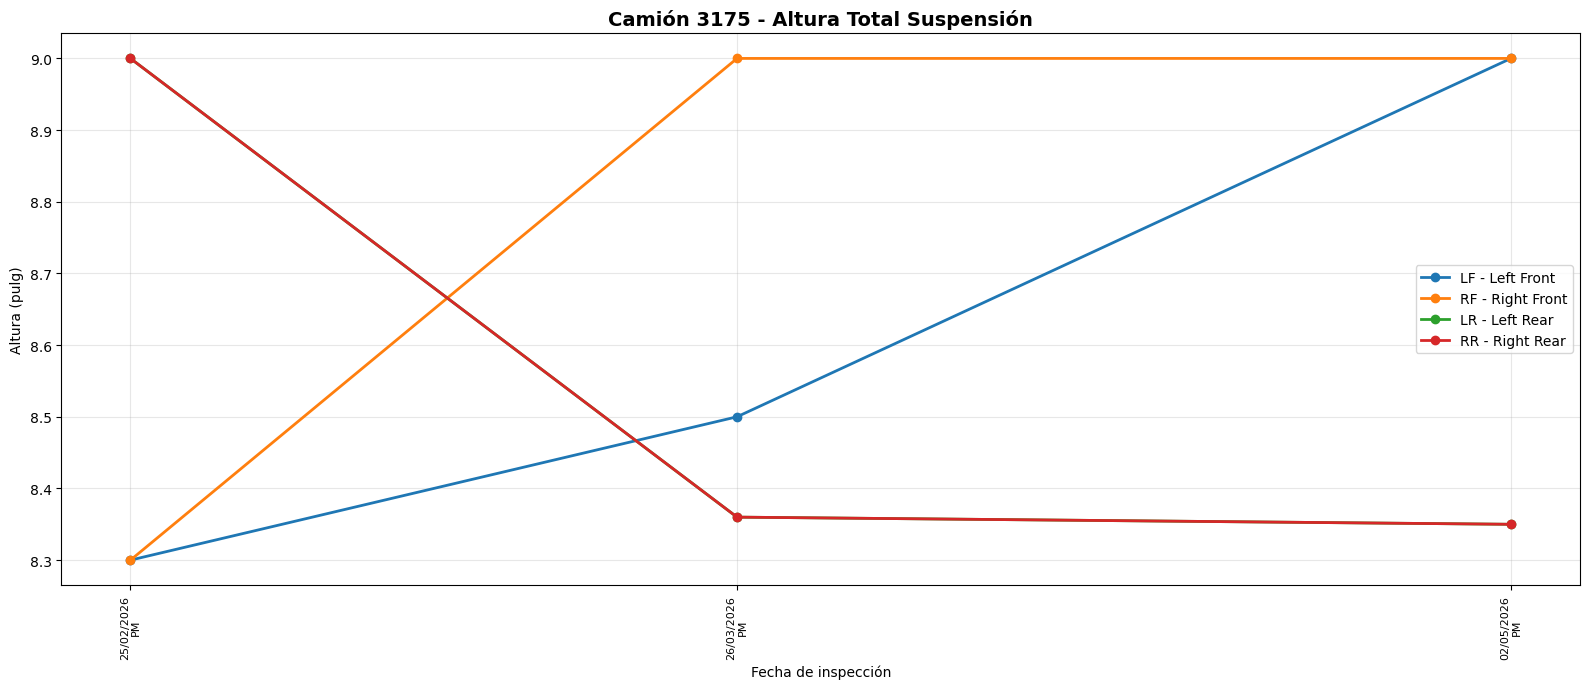

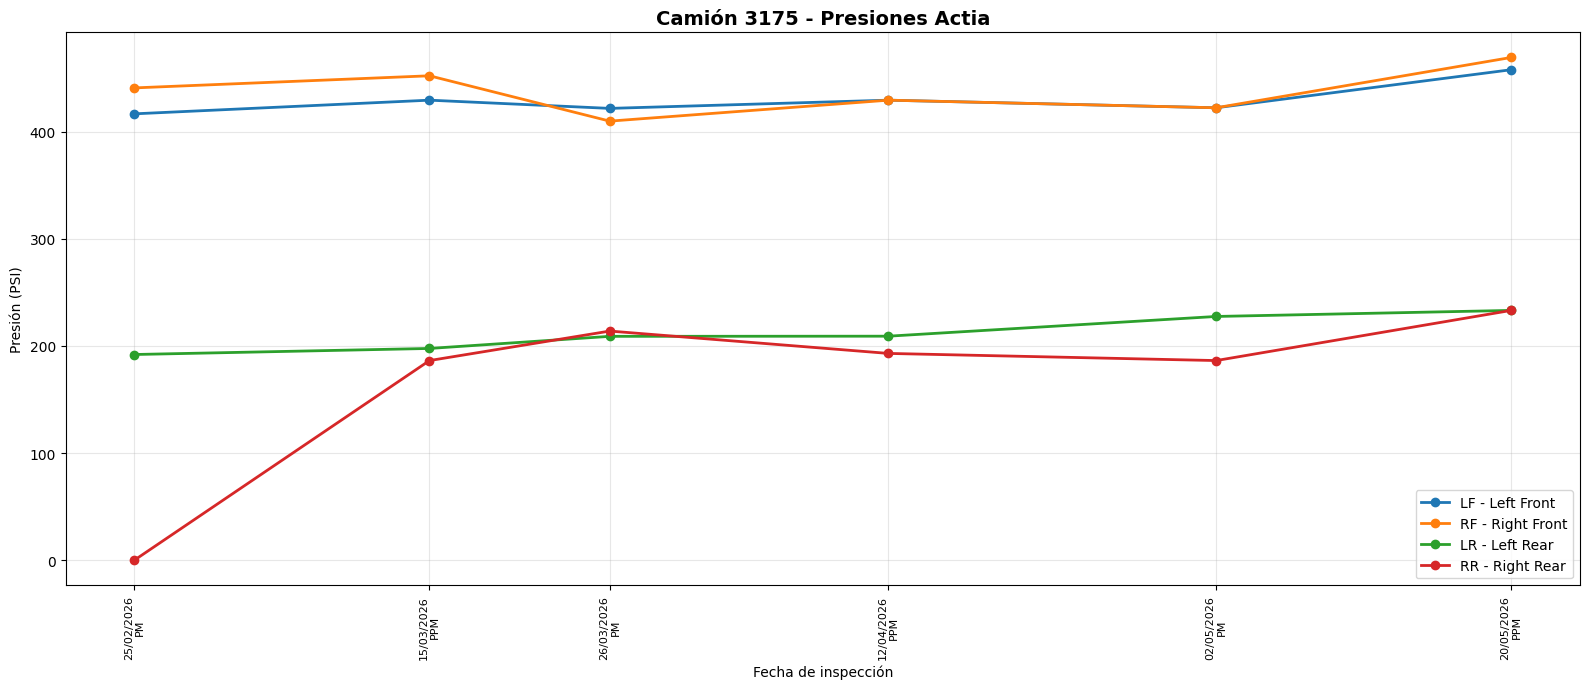

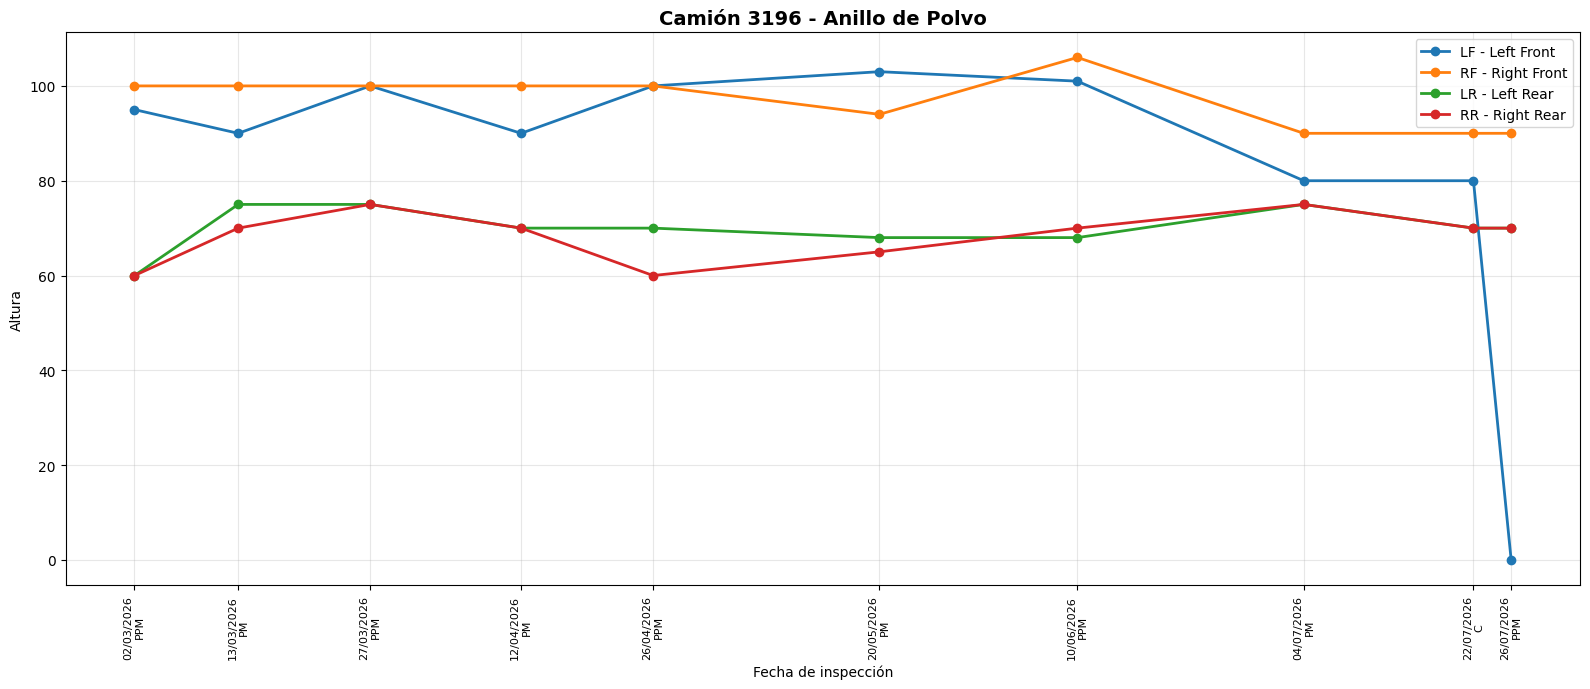

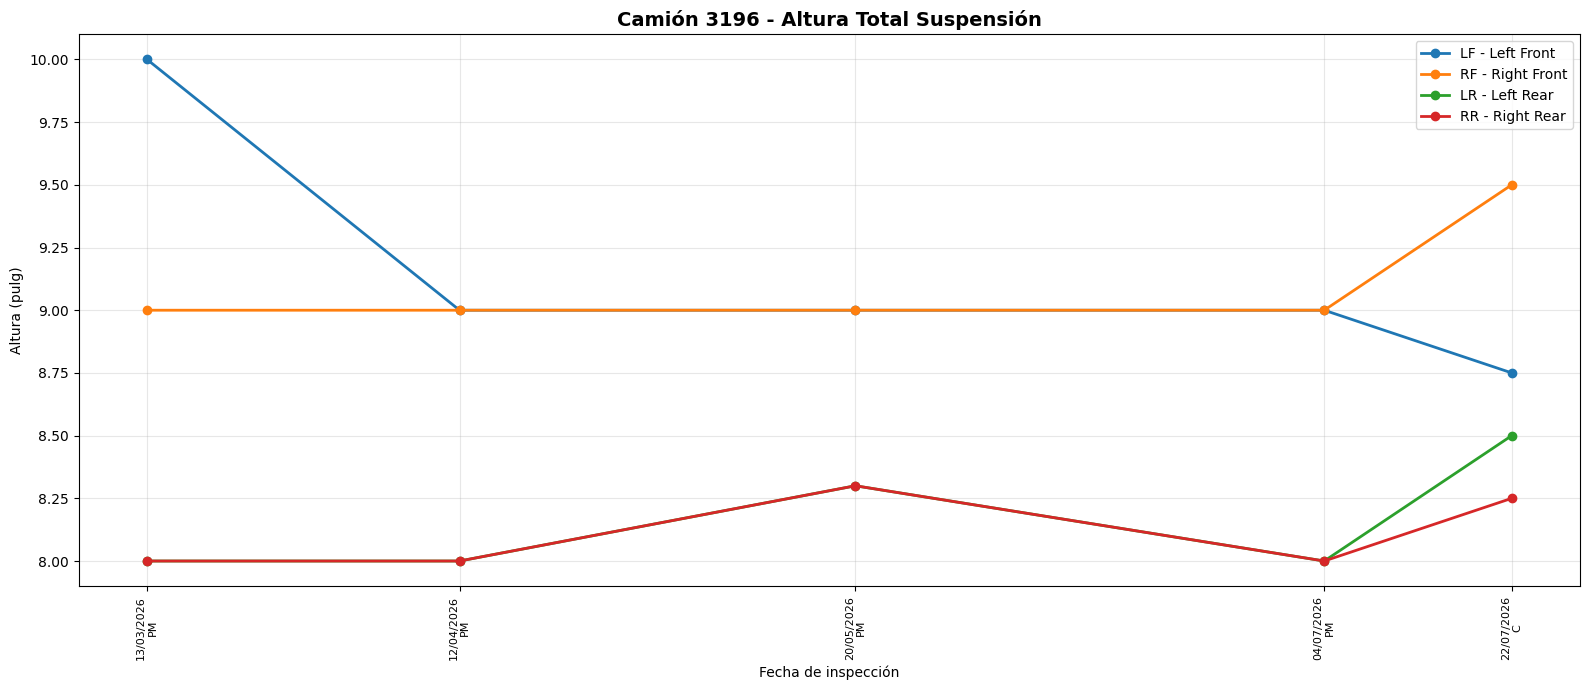

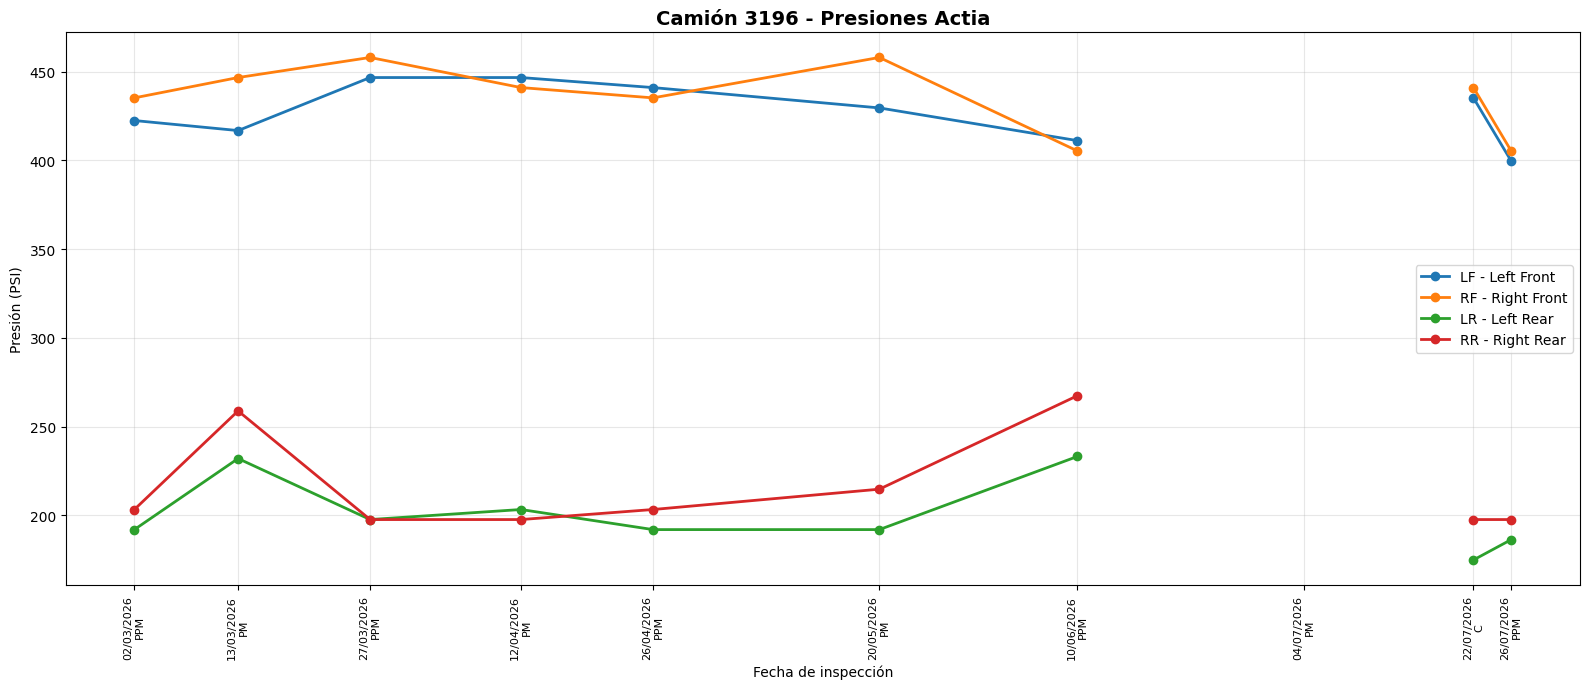

Gráficas generadas correctamente.


In [ ]:
# =========================================================
# LIBRERIAS
# =========================================================
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# FORMATO FECHA
# =========================================================
df['Fecha'] = pd.to_datetime(
    df['Fecha'],
    dayfirst=True,
    errors='coerce'
)

# Eliminar filas con fecha inválida
df = df.dropna(subset=['Fecha'])

# =========================================================
# LIMPIAR COLUMNA TIPO
# =========================================================
# La columna debe contener: PM, PPM o Correctivo
df['Tipo'] = (
    df['Tipo']
    .fillna('Sin especificar')
    .astype(str)
    .str.strip()
)

# Estandarizar nombres
df['Tipo'] = df['Tipo'].replace({
    'pm': 'PM',
    'Pm': 'PM',
    'ppm': 'PPM',
    'Ppm': 'PPM',
    'correctivo': 'Correctivo',
    'CORRECTIVO': 'Correctivo'
})

# Abreviar Correctivo para la etiqueta del gráfico
df['Tipo_Etiqueta'] = df['Tipo'].replace({
    'Correctivo': 'C'
})

# =========================================================
# ORDENAR
# =========================================================
df = df.sort_values(['Camion', 'Fecha'])

# =========================================================
# CREAR CARPETA
# =========================================================
output_dir = Path("Graficas_Suspension")
output_dir.mkdir(exist_ok=True)

# =========================================================
# CONFIGURACION GRAFICAS
# =========================================================
graficas = {

    'AP': {
        'cols': ['AP LF', 'AP RF', 'AP LR', 'AP RR'],
        'titulo': 'Anillo de Polvo',
        'ylabel': 'Altura'
    },

    'AT': {
        'cols': ['AT LF', 'AT RF', 'AT LR', 'AT RR'],
        'titulo': 'Altura Total Suspensión',
        'ylabel': 'Altura (pulg)'
    },

    'PA': {
        'cols': ['PA LF', 'PA RF', 'PA LR', 'PA RR'],
        'titulo': 'Presiones Actia',
        'ylabel': 'Presión (PSI)'
    }
}

# =========================================================
# NOMBRES
# =========================================================
labels = {
    'LF': 'LF - Left Front',
    'RF': 'RF - Right Front',
    'LR': 'LR - Left Rear',
    'RR': 'RR - Right Rear'
}

# =========================================================
# GRAFICAR POR CAMION
# =========================================================
for camion in df['Camion'].dropna().unique():

    df_camion = df[df['Camion'] == camion].copy()

    # Asegurar orden cronológico
    df_camion = df_camion.sort_values('Fecha')

    for key, info in graficas.items():

        # -------------------------------------------------
        # FILTRO ESPECIAL PARA ALTURA TOTAL DE SUSPENSIÓN
        # -------------------------------------------------
        if key == 'AT':

            # Solo PM y Correctivo
            df_camion_plot = df_camion[
                df_camion['Tipo'].isin(['PM', 'Correctivo'])
            ].copy()

            # Eliminar filas donde las cuatro alturas estén vacías
            df_camion_plot = df_camion_plot.dropna(
                subset=info['cols'],
                how='all'
            )

        else:
            # AP y PA muestran todos los registros
            df_camion_plot = df_camion.copy()

        # Si no hay datos, no generar la gráfica
        if df_camion_plot.empty:
            print(
                f"Sin datos para Camión {camion} - {info['titulo']}"
            )
            continue

        plt.figure(figsize=(16, 7))

        # -------------------------------------------------
        # GRAFICAR LAS 4 POSICIONES
        # -------------------------------------------------
        for col in info['cols']:

            posicion = col.split()[-1]

            plt.plot(
                df_camion_plot['Fecha'],
                df_camion_plot[col],
                marker='o',
                linewidth=2,
                markersize=6,
                label=labels[posicion]
            )

        # -------------------------------------------------
        # TITULOS Y EJES
        # -------------------------------------------------
        plt.title(
            f'Camión {camion} - {info["titulo"]}',
            fontsize=14,
            fontweight='bold'
        )

        plt.xlabel('Fecha de inspección')
        plt.ylabel(info['ylabel'])

        # -------------------------------------------------
        # ETIQUETAS DEL EJE X: FECHA + TIPO
        # -------------------------------------------------
        etiquetas = [
            f"{fecha.strftime('%d/%m/%Y')}\n{tipo}"
            for fecha, tipo in zip(
                df_camion_plot['Fecha'],
                df_camion_plot['Tipo_Etiqueta']
            )
        ]

        plt.xticks(
            ticks=df_camion_plot['Fecha'],
            labels=etiquetas,
            rotation=90,
            fontsize=8
        )

        plt.grid(True, alpha=0.3)
        plt.legend()

        # Dar espacio para las etiquetas inferiores
        plt.subplots_adjust(bottom=0.25)

        plt.tight_layout()

        # -------------------------------------------------
        # GUARDAR
        # -------------------------------------------------
        nombre = output_dir / f'{camion}_{key}.png'

        plt.savefig(
            nombre,
            dpi=300,
            bbox_inches='tight'
        )

        plt.show()
        plt.close()

# =========================================================
# FINAL
# =========================================================
print("Gráficas generadas correctamente.")